In [1]:
!pip install statsmodels


In [2]:
# %% [markdown]
# # BTC Hourly — Backtest e treino de modelos (walk-forward)
#
# - Carregamento do master dataset horário de Bitcoin.
# - Construção de alvos y_ret_tH para H ∈ {1, 6, 24}.
# - Selecção global de features (cobertura / variância).
# - Geração de splits walk-forward com purga temporal.
# - Treino e avaliação de modelos (Naive0, NaiveLast, OLS, RF, ARIMA, SARIMA, LSTM opcional).
# - Registo detalhado por split (tamanho treino/teste, features, métricas).
# - Ficheiros CSV:
#   - per_split_metrics.csv (todos os modelos e splits)
#   - per_split_metrics_<Modelo>.csv (um ficheiro por modelo)
#   - summary_metrics_by_H.csv (médias por H e modelo)


# %% 1 – Imports base, paths e configuração

import os
import math
import random
import warnings
from typing import List, Tuple, Dict, Optional

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd

# Reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Paths master dataset
IN_PARQ = "data/out/btc_master_hourly_2017_2025.parquet"
IN_CSV  = "data/out/btc_master_hourly_2017_2025.csv"

# Pasta para resultados deste notebook
DIR_RES = "data/out/results_models"
os.makedirs(DIR_RES, exist_ok=True)

PER_SPLIT = os.path.join(DIR_RES, "per_split_metrics.csv")
SUMMARY   = os.path.join(DIR_RES, "summary_metrics_by_H.csv")

In [3]:
# %% 2 – Função para carregar master dataset

def load_master() -> pd.DataFrame:
    """Carrega o master dataset horário (parquet preferencial, csv como fallback)."""
    if os.path.exists(IN_PARQ):
        df_ = pd.read_parquet(IN_PARQ)
        # se o index não for datetime, tentar converter
        if not isinstance(df_.index, pd.DatetimeIndex):
            df_.index = pd.to_datetime(df_.index, utc=True, errors="coerce")
        df_ = df_[~df_.index.isna()]
        return df_.sort_index()

    if os.path.exists(IN_CSV):
        df_ = pd.read_csv(IN_CSV)
        # tentativa de detecção da coluna temporal
        dt_col = None
        for c in ["open_time", "timestamp", "date", "datetime", "time", "Date"]:
            if c in df_.columns:
                dt_col = c
                break
        if dt_col is None:
            dt_col = df_.columns[0]
        df_[dt_col] = pd.to_datetime(df_[dt_col], utc=True, errors="coerce")
        df_ = df_.dropna(subset=[dt_col])
        return df_.sort_values(dt_col).set_index(dt_col)

    raise FileNotFoundError("Master dataset não encontrado (esperava IN_PARQ ou IN_CSV).")


df = load_master()
df.head()


,Unnamed: 0,open,high,low,close,volume,close_time,quote_vol,trades,taker_buy_base,...,sent_Short Description,sent_Accurate Sentiments,sent_asof_date,date,hash-rate,hash_asof_date,log_close,ret_t,y_ret_t1,y_dir_t1
open_time,,,,,,,,,,,,,,,,,,,,,
2017-08-17 04:00:00+00:00,0.0,4261.48,4313.62,4261.32,4308.83,47.181009,2017-08-17 04:59:59.999,202366.138393,171.0,35.160503,...,NaN,NaN,NaT,NaN,NaN,NaT,8.368422,NaN,0.001505,1.0
2017-08-17 05:00:00+00:00,1.0,4308.83,4328.69,4291.37,4315.32,23.234916,2017-08-17 05:59:59.999,100304.823567,102.0,21.448071,...,NaN,NaN,NaT,NaN,NaN,NaT,8.369927,0.001505,0.002090,1.0
2017-08-17 06:00:00+00:00,2.0,4330.29,4345.45,4309.37,4324.35,7.229691,2017-08-17 06:59:59.999,31282.312670,36.0,4.802861,...,NaN,NaN,NaT,NaN,NaN,NaT,8.372017,0.002090,0.005912,1.0
2017-08-17 07:00:00+00:00,3.0,4316.62,4349.99,4287.41,4349.99,4.443249,2017-08-17 07:59:59.999,19241.058300,25.0,2.602292,...,NaN,NaN,NaT,NaN,NaN,NaT,8.377929,0.005912,0.002457,1.0
2017-08-17 08:00:00+00:00,4.0,4333.32,4377.85,4333.32,4360.69,0.972807,2017-08-17 08:59:59.999,4239.503586,28.0,0.814655,...,NaN,NaN,NaT,NaN,NaN,NaT,8.380386,0.002457,0.018925,1.0


In [4]:

# %% 3 – Normalização do índice temporal

df.index = pd.to_datetime(df.index, utc=True, errors="coerce")
df = df[~df.index.isna()].sort_index()

if not isinstance(df.index, pd.DatetimeIndex):
    raise TypeError("Index não é DatetimeIndex depois do parsing.")

df.index.freq  # normalmente None, não faz mal


# %% 4 – Horizontes de previsão e construção dos targets (HORIZONS)

# Garantir log_close
if "log_close" not in df.columns:
    if "close" in df.columns:
        df["log_close"] = np.log(df["close"])
    else:
        raise ValueError("Nem 'log_close' nem 'close' existem em df para construir log_close.")

# Garantir ret_t (retorno horário)
if "ret_t" not in df.columns:
    df["ret_t"] = df["log_close"].diff()

# Horizontes de previsão
HORIZONS = [1, 6, 24]

# Construir targets y_ret_tH e direcção y_dir_tH
for H in HORIZONS:
    df[f"y_ret_t{H}"] = df["log_close"].shift(-H) - df["log_close"]
    df[f"y_dir_t{H}"] = np.sign(df[f"y_ret_t{H}"]).astype("float32")

# Cortar cauda onde o maior horizonte não tem target definido
max_H = max(HORIZONS)
mask_valid = ~df[f"y_ret_t{max_H}"].isna()
df = df.loc[mask_valid].copy()

df[[f"y_ret_t{h}" for h in HORIZONS]].describe().T



,count,mean,std,min,25%,50%,75%,max
y_ret_t1,64554.0,0.000045,0.008173,-0.201033,-0.002577,0.000089,0.002762,0.160280
y_ret_t6,64496.0,0.000274,0.018748,-0.379549,-0.006053,0.000353,0.007039,0.265346
y_ret_t24,64582.0,0.001117,0.037760,-0.624510,-0.014264,0.001022,0.017497,0.298704


In [5]:
# %% 5 – Selecção global de features numéricas (FEATS)

# seleccionar apenas colunas numéricas
numeric = df.select_dtypes(include=[np.number]).copy()

# excluir targets e variáveis que não queremos como input
exclude_cols = {f"y_ret_t{H}" for H in HORIZONS} \
             | {f"y_dir_t{H}" for H in HORIZONS} \
             | {"log_close", "close"}

# candidatos a feature = todas as numéricas menos as excluídas
cand = [c for c in numeric.columns if c not in exclude_cols]

# cobertura (proporção de não-NaN) por coluna
coverage = numeric[cand].notna().mean()

# threshold mínimo de cobertura global
MIN_GLOBAL_COVERAGE = 0.50

FEATS = [
    c for c in cand
    if coverage.get(c, 0) >= MIN_GLOBAL_COVERAGE
    and numeric[c].nunique(dropna=True) > 1  # descarta constantes
]

# se ficarmos com poucas features, relaxar progressivamente o threshold
if len(FEATS) < 3:
    for thr in [0.40, 0.30, 0.20, 0.10]:
        FEATS = [
            c for c in cand
            if numeric[c].notna().mean() >= thr
            and numeric[c].nunique(dropna=True) > 1
        ]
        if len(FEATS) >= 3:
            print(f"⚠️ FEATS definido com threshold mais baixo: {thr:.2f}")
            break

# garantir que 'ret_t' entra se existir e tiver dados
if "ret_t" in df.columns and df["ret_t"].notna().any():
    if "ret_t" not in FEATS:
        FEATS = ["ret_t"] + FEATS

if not FEATS:
    raise RuntimeError(
        "Sem features numéricas utilizáveis após filtragem global. "
        "Verifica o output do ETL / colunas numéricas."
    )

print(f"Número de features seleccionadas: {len(FEATS)}")
print("Primeiras features:", FEATS[:15])


Número de features seleccionadas: 104
Primeiras features: ['Unnamed: 0', 'open', 'high', 'low', 'volume', 'quote_vol', 'trades', 'taker_buy_base', 'taker_buy_quote', 'volume_adi', 'volume_obv', 'volume_cmf', 'volume_fi', 'volume_em', 'volume_sma_em']


In [6]:
# %% 6 – Janela de backtest e geração de SPLITS walk-forward

def pick_test_window(idx: pd.DatetimeIndex) -> Tuple[str, str]:
    """
    Escolhe a janela de backtest:
    - por defeito: último ano civil se houver ≥ 1 mês de dados horários;
    - caso contrário: últimos 365 dias em relação ao máximo timestamp.
    """
    idx = idx.sort_values()
    years = sorted(set(idx.year))
    last_year = years[-1]
    in_year = idx[idx.year == last_year]
    if len(in_year) >= 24 * 30:
        return f"{last_year}-01-01", f"{last_year}-12-31"
    end = idx.max().floor("H")
    start = end - pd.Timedelta(days=365)
    return start.strftime("%Y-%m-%d"), end.strftime("%Y-%m-%d")


test_start, test_end = pick_test_window(df.index)
print(f"Janela inicial de backtest: {test_start} → {test_end}")


def walk_forward_splits(index: pd.DatetimeIndex,
                        test_start: str,
                        test_end: str,
                        block_hours: int = 24 * 7,
                        min_train_hours: int = 24 * 180,
                        purge_hours: int = 24) -> List[Tuple[pd.DatetimeIndex, pd.DatetimeIndex]]:
    """
    Gera splits walk-forward:
    - blocos de teste de tamanho fixo (block_hours),
    - treino mínimo (min_train_hours),
    - zona de purga entre treino e teste (purge_hours).
    """
    idx = pd.DatetimeIndex(index).sort_values()
    start = pd.Timestamp(test_start, tz="UTC")
    end   = pd.Timestamp(test_end,   tz="UTC")
    f = idx[(idx >= start) & (idx <= end)]
    splits: List[Tuple[pd.DatetimeIndex, pd.DatetimeIndex]] = []
    if len(f) == 0:
        return splits

    curr = f.min()
    while curr <= f.max():
        test_stop = curr + pd.Timedelta(hours=block_hours - 1)
        test_idx = idx[(idx >= curr) & (idx <= min(test_stop, f.max()))]
        if len(test_idx) == 0:
            break

        train_cut = curr - pd.Timedelta(hours=purge_hours)
        train_idx = idx[idx < train_cut]

        if len(train_idx) >= min_train_hours:
            splits.append((train_idx, test_idx))

        curr = test_stop + pd.Timedelta(hours=1)

    return splits


def ensure_splits(idx: pd.DatetimeIndex):
    """
    Tenta várias combinações (min_train_hours, block_hours)
    até obter pelo menos um split válido.
    """
    trials = [
        (24 * 180, 24 * 7),
        (24 * 120, 24 * 7),
        (24 * 90,  24 * 7),
        (24 * 60,  24 * 3),
        (24 * 45,  24 * 3),
        (24 * 30,  24 * 1),
    ]
    for mth, bh in trials:
        s = walk_forward_splits(
            idx,
            test_start=test_start,
            test_end=test_end,
            block_hours=bh,
            min_train_hours=mth,
            purge_hours=24,
        )
        if len(s) > 0:
            print(f"Usar splits: min_train_hours={mth}, block_hours={bh}, count={len(s)}")
            return s
    return []


# construir SPLITS com janela inicial
SPLITS = ensure_splits(df.index)

# fallback: se nada funcionar, tentar últimos 180 dias como search space
if not SPLITS:
    end = df.index.max().floor("H")
    start = (end - pd.Timedelta(days=180)).strftime("%Y-%m-%d")
    test_start, test_end = start, end.strftime("%Y-%m-%d")
    print(f"Fallback: nova janela {test_start} → {test_end}")
    SPLITS = ensure_splits(df.index)
    if not SPLITS:
        raise RuntimeError("Não foi possível construir nenhum split walk-forward. Verificar dados.")

print(f"Número de splits obtidos: {len(SPLITS)}")

Janela inicial de backtest: 2024-01-09 → 2025-01-08
Usar splits: min_train_hours=4320, block_hours=168, count=53
Número de splits obtidos: 53


In [7]:
# %% 7 – Métricas, modelos e auxiliares (inclui SimpleImputer e ARIMA silencioso)

import warnings

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from scipy.stats import t as tdist

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning

# LSTM (opcional)
USE_LSTM = False
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models, callbacks
except Exception:
    USE_LSTM = False
    print("TensorFlow não disponível; LSTM será ignorado.")

EPS = 1e-12


def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def smape(y, yhat) -> float:
    y, yhat = np.asarray(y), np.asarray(yhat)
    return 2 * np.mean(np.abs(y - yhat) / (np.abs(y) + np.abs(yhat) + EPS))


def mase(y_true, y_pred, insample, seasonality=24) -> float:
    ins = np.asarray(insample)
    if len(ins) <= seasonality:
        return np.nan
    denom = np.mean(np.abs(ins[seasonality:] - ins[:-seasonality]))
    if denom < EPS:
        return np.nan
    return np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))) / denom


def directional_accuracy(y, yhat) -> float:
    return float((np.sign(y) == np.sign(yhat)).mean())


def safe_f1(y_true, y_pred) -> float:
    yt = (np.asarray(y_true) > 0).astype(int)
    yp = (np.asarray(y_pred) > 0).astype(int)
    if len(np.unique(yt)) < 2 or len(np.unique(yp)) < 2:
        return np.nan
    try:
        return f1_score(yt, yp)
    except Exception:
        return np.nan


def dm_test(e_model, e_bench, power=2):
    e1, e2 = np.asarray(e_model), np.asarray(e_bench)
    d = (np.abs(e1) - np.abs(e2)) if power == 1 else (e1**2 - e2**2)
    n = len(d)
    if n < 3:
        return np.nan, 1.0
    v = d.var(ddof=1)
    if v <= 0:
        return np.nan, 1.0
    stat = d.mean() / math.sqrt(v / n)
    p = 2 * (1 - tdist.cdf(abs(stat), df=n-1))
    return stat, p


def model_OLS():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LinearRegression())
    ])


def model_RF():
    return RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )


# Naive models
def predict_naive0(index_subset):
    return np.zeros(len(index_subset), dtype=float)


def predict_naivelast(ret_series: pd.Series, index_subset):
    preds = []
    for ts in index_subset:
        prev = ts - pd.Timedelta(hours=1)
        preds.append(ret_series.loc[prev] if prev in ret_series.index else 0.0)
    return np.array(preds, dtype=float)


# Série global para NaiveLast
RET_SERIES_FOR_LAST = df["ret_t"].fillna(0.0)


def forecast_arima_like(H, train_idx, test_idx, seasonal=False):
    """
    Ajusta ARIMA/SARIMA sobre log_close (train_idx) e devolve previsões de log-return H steps ahead.
    Avisos de frequência de índice e convergência são suprimidos localmente.
    """
    log_close = df["log_close"]
    train_idx = pd.DatetimeIndex(train_idx)
    test_idx  = pd.DatetimeIndex(test_idx)

    valid_train_idx = train_idx.intersection(log_close.index)
    train_series = log_close.loc[valid_train_idx].dropna()

    if len(train_series) < 24 * 30:
        return None, None

    train_end = train_series.index.max()
    last_needed = test_idx.max() + pd.Timedelta(hours=H)
    n_hours = int((last_needed - train_end) / pd.Timedelta(hours=1))
    if n_hours <= 0:
        return None, None

    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=UserWarning)
            warnings.filterwarnings("ignore", category=ConvergenceWarning)
            warnings.filterwarnings("ignore", category=ValueWarning)

            if seasonal:
                model = SARIMAX(
                    train_series,
                    order=(1, 1, 1),
                    seasonal_order=(1, 0, 1, 24),
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                )
            else:
                model = ARIMA(train_series, order=(1, 1, 1))

            fit = model.fit()
    except Exception:
        return None, None

    fc = fit.forecast(steps=n_hours)

    fc_index = pd.date_range(
        start=train_end + pd.Timedelta(hours=1),
        periods=n_hours,
        freq="H"
    )
    fc_series = pd.Series(fc.values, index=fc_index)

    idx_list, preds = [], []
    for t in test_idx:
        if t not in log_close.index:
            continue
        t_future = t + pd.Timedelta(hours=H)
        if t_future not in fc_series.index:
            continue
        base_val = log_close.loc[t]
        if pd.isna(base_val):
            continue
        ret_hat = fc_series.loc[t_future] - base_val
        idx_list.append(t)
        preds.append(ret_hat)

    if not idx_list:
        return None, None

    return pd.DatetimeIndex(idx_list), np.array(preds, dtype=float)


# LSTM helpers
LSTM_LOOKBACK = 48
LSTM_EPOCHS = 20
LSTM_BATCH = 64
MIN_LSTM_TRAIN_SEQ = 200
MIN_LSTM_TEST_SEQ = 20


def make_lstm_sequences(X_df: pd.DataFrame,
                        y_series: pd.Series,
                        lookback: int):
    idx = X_df.index.sort_values()
    X_seq, y_seq, centers = [], [], []
    for i in range(lookback, len(idx)):
        window_idx = idx[i - lookback:i]
        t = idx[i]
        if t not in y_series.index:
            continue
        y_val = y_series.loc[t]
        if pd.isna(y_val):
            continue
        X_seq.append(X_df.loc[window_idx].values)
        y_seq.append(y_val)
        centers.append(t)

    if not X_seq:
        return None, None, None

    return np.array(X_seq, dtype=float), np.array(y_seq, dtype=float), pd.DatetimeIndex(centers)


def build_lstm_model(n_timesteps: int, n_features: int):
    model = models.Sequential([
        layers.Input(shape=(n_timesteps, n_features)),
        layers.LSTM(64, return_sequences=False),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="linear")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse"
    )
    return model


# Escolha de modelos activos (para poderes testar um de cada vez)
ACTIVE_MODELS = {
    "Naive0",
    "NaiveLast",
    "OLS",
    "RF",
    "ARIMA",
    "SARIMA",
}
if USE_LSTM:
    ACTIVE_MODELS.add("LSTM")

print("Modelos activos:", sorted(ACTIVE_MODELS))


2025-12-16 15:31:43.573150: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-16 15:31:43.787152: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-16 15:31:44.844012: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Modelos activos: ['ARIMA', 'Naive0', 'NaiveLast', 'OLS', 'RF', 'SARIMA']


In [8]:
if USE_LSTM:
    print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
    print("Devices: ", tf.config.list_physical_devices())

In [9]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# ---------------------------------------------------------
# CONFIGURAÇÃO PYTORCH (GPU)
# ---------------------------------------------------------
# Verifica se a GPU está disponível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch a usar: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Definição do Modelo LSTM em PyTorch
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=50, output_dim=1):
        super(LSTMModel, self).__init__()
        # batch_first=True espera entrada (batch, seq_len, features)
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x shape: (batch, seq_len, input_dim)
        # out shape: (batch, seq_len, hidden_dim)
        out, (hn, cn) = self.lstm(x)
        # Usamos apenas o output do último passo temporal
        last_step = out[:, -1, :] 
        prediction = self.fc(last_step)
        return prediction

# %% 8 – Backtest walk-forward + treino e logging por split

rows: List[Dict] = []
imp = SimpleImputer(strategy="median")

# Create a list of tasks to track progress
total_steps = len(HORIZONS) * len(SPLITS)
pbar = tqdm(total=total_steps, desc="Backtesting Progress")

for H in HORIZONS:
    tgt = f"y_ret_t{H}"
    y_all = df[tgt].copy()

    for split_id, (train_idx, test_idx) in enumerate(SPLITS, start=1):
        
        # Update progress bar description
        pbar.set_description(f"H={H} | Split={split_id}/{len(SPLITS)}")
        
        # X, y brutos deste split
        Xtr_raw = df.loc[train_idx, FEATS].copy()
        Xte_raw = df.loc[test_idx, FEATS].copy()
        ytr_full = y_all.loc[train_idx]
        yte_full = y_all.loc[test_idx]

        # Per-split feature pruning: cobertura >= 70% e não constantes em TRAIN
        train_cov = Xtr_raw.notna().mean()
        good_cols = [
            c for c in Xtr_raw.columns
            if train_cov[c] >= 0.70 and Xtr_raw[c].nunique(dropna=True) > 1
        ]
        if not good_cols:
            pbar.update(1)
            continue

        Xtr_raw = Xtr_raw[good_cols]
        Xte_raw = Xte_raw[good_cols]

        # Imputação baseada em TRAIN
        imp.fit(Xtr_raw)
        Xtr = pd.DataFrame(
            imp.transform(Xtr_raw),
            index=Xtr_raw.index,
            columns=good_cols
        )
        Xte = pd.DataFrame(
            imp.transform(Xte_raw),
            index=Xte_raw.index,
            columns=good_cols
        )

        # Alinhar y com X e tirar NaN do target
        ytr = ytr_full.loc[Xtr.index].dropna()
        Xtr = Xtr.loc[ytr.index]

        yte = yte_full.loc[Xte.index].dropna()
        Xte = Xte.loc[yte.index]

        if len(Xtr) == 0 or len(Xte) == 0:
            pbar.update(1)
            continue

        Xtr = Xtr.sort_index()
        Xte = Xte.sort_index()

        insample_y = ytr.values  # para MASE

        # Meta-dados deste split
        train_start = Xtr.index.min()
        train_end   = Xtr.index.max()
        test_start_eff = Xte.index.min()
        test_end_eff   = Xte.index.max()
        n_train = len(Xtr)
        n_test  = len(Xte)
        n_features = Xtr.shape[1]
        feat_list_str = ",".join(Xtr.columns.astype(str))

        test_idx_eff = Xte.index

        # Baselines Naive
        yhat_naive0_full     = predict_naive0(test_idx_eff)
        yhat_naivelast_full  = predict_naivelast(RET_SERIES_FOR_LAST, test_idx_eff)

        def log_result(model_name: str,
                       index_subset: pd.DatetimeIndex,
                       yhat_array):
            index_subset = pd.DatetimeIndex(index_subset).sort_values()
            if len(index_subset) == 0:
                return

            y_true_series = y_all.loc[index_subset]
            mask = ~y_true_series.isna()
            if not mask.any():
                return
            idx_valid = index_subset[mask]
            y_true = y_true_series.loc[idx_valid].values

            yhat_array = np.asarray(yhat_array)
            yhat = yhat_array[mask.values]
            if len(y_true) == 0 or len(y_true) != len(yhat):
                return

            yhat_bench = predict_naive0(idx_valid)
            err_bench = y_true - yhat_bench
            err_model = y_true - yhat

            mae       = mean_absolute_error(y_true, yhat)
            rmse_val  = rmse(y_true, yhat)
            r2        = r2_score(y_true, yhat)
            smape_val = smape(y_true, yhat)
            mase_val  = mase(y_true, yhat, insample=insample_y, seasonality=24)
            da_val    = directional_accuracy(y_true, yhat)
            f1_val    = safe_f1(y_true, yhat)

            dm_stat, dm_p = dm_test(err_model, err_bench, power=2)
            if model_name == "Naive0":
                dm_stat, dm_p = np.nan, 1.0

            rows.append({
                "H": H,
                "Split": split_id,
                "Model": model_name,
                "train_start": train_start,
                "train_end": train_end,
                "test_start": test_start_eff,
                "test_end": test_end_eff,
                "n_train": int(n_train),
                "n_test": int(n_test),
                "n_features": int(n_features),
                "features": feat_list_str,
                "MAE": mae,
                "RMSE": rmse_val,
                "R2": r2,
                "sMAPE": smape_val,
                "MASE": mase_val,
                "DA": da_val,
                "F1": f1_val,
                "DM_stat_vsNaive0": dm_stat,
                "DM_p_vsNaive0": dm_p,
            })

        # -------- Naive0
        if "Naive0" in ACTIVE_MODELS:
            log_result("Naive0", test_idx_eff, yhat_naive0_full)

        # -------- NaiveLast
        if "NaiveLast" in ACTIVE_MODELS:
            log_result("NaiveLast", test_idx_eff, yhat_naivelast_full)

        # -------- OLS
        if "OLS" in ACTIVE_MODELS:
            ols = model_OLS()
            ols.fit(Xtr, ytr)
            yhat_ols = ols.predict(Xte)
            log_result("OLS", test_idx_eff, yhat_ols)

        # -------- Random Forest (Actually HistGradientBoosting now)
        if "RF" in ACTIVE_MODELS:
            rf = model_RF()
            rf.fit(Xtr, ytr)
            yhat_rf = rf.predict(Xte)
            log_result("RF", test_idx_eff, yhat_rf)

        # -------- ARIMA
        if "ARIMA" in ACTIVE_MODELS:
            idx_arima, yhat_arima = forecast_arima_like(
                H,
                train_idx=train_idx,
                test_idx=test_idx_eff,
                seasonal=False
            )
            if idx_arima is not None:
                log_result("ARIMA", idx_arima, yhat_arima)

        # -------- LSTM (IMPLEMENTAÇÃO PYTORCH)
        if USE_LSTM and "LSTM" in ACTIVE_MODELS:
            try:
                # 1. Preparação de Dados (igual ao Keras)
                scaler_seq = StandardScaler()
                Xtr_vals = scaler_seq.fit_transform(Xtr.values)
                Xte_vals = scaler_seq.transform(Xte.values)
                
                Xtr_s = pd.DataFrame(Xtr_vals, index=Xtr.index, columns=Xtr.columns)
                Xte_s = pd.DataFrame(Xte_vals, index=Xte.index, columns=Xte.columns)

                Xtr_seq, ytr_seq, idx_tr_seq = make_lstm_sequences(
                    Xtr_s, ytr, LSTM_LOOKBACK
                )
                Xte_seq, yte_seq, idx_te_seq = make_lstm_sequences(
                    Xte_s, y_all, LSTM_LOOKBACK
                )

                if (Xtr_seq is not None and Xte_seq is not None and
                        len(Xtr_seq) >= MIN_LSTM_TRAIN_SEQ and
                        len(Xte_seq) >= MIN_LSTM_TEST_SEQ):

                    # 2. Conversão para Tensores PyTorch
                    X_train_t = torch.tensor(Xtr_seq, dtype=torch.float32)
                    y_train_t = torch.tensor(ytr_seq, dtype=torch.float32).unsqueeze(1)
                    X_test_t  = torch.tensor(Xte_seq, dtype=torch.float32).to(device)
                    
                    # Simular validation_split=0.1
                    val_size = int(len(X_train_t) * 0.1)
                    train_size = len(X_train_t) - val_size
                    
                    X_t, X_v = X_train_t[:train_size], X_train_t[train_size:]
                    y_t, y_v = y_train_t[:train_size], y_train_t[train_size:]
                    
                    # Dataloaders para batching
                    train_data = TensorDataset(X_t.to(device), y_t.to(device))
                    val_data   = TensorDataset(X_v.to(device), y_v.to(device))
                    
                    train_loader = DataLoader(train_data, batch_size=LSTM_BATCH, shuffle=False)
                    # Validação pode ser em batch maior ou full
                    val_loader   = DataLoader(val_data, batch_size=LSTM_BATCH, shuffle=False)

                    # 3. Inicializar Modelo, Loss e Optimizer
                    input_features = Xtr_seq.shape[2]
                    model = LSTMModel(input_features).to(device)
                    criterion = nn.MSELoss()
                    optimizer = optim.Adam(model.parameters(), lr=0.001)

                    # 4. Loop de Treino com Early Stopping
                    best_val_loss = float('inf')
                    patience = 3
                    counter = 0
                    best_weights = None

                    for epoch in range(LSTM_EPOCHS):
                        # Treino
                        model.train()
                        for X_batch, y_batch in train_loader:
                            optimizer.zero_grad()
                            outputs = model(X_batch)
                            loss = criterion(outputs, y_batch)
                            loss.backward()
                            optimizer.step()
                        
                        # Validação
                        model.eval()
                        val_loss = 0.0
                        with torch.no_grad():
                            for X_val_b, y_val_b in val_loader:
                                preds = model(X_val_b)
                                val_loss += criterion(preds, y_val_b).item() * X_val_b.size(0)
                        val_loss /= len(val_data)

                        # Check Early Stopping
                        if val_loss < best_val_loss:
                            best_val_loss = val_loss
                            counter = 0
                            # Guardar pesos (state_dict) em memória
                            best_weights = model.state_dict()
                        else:
                            counter += 1
                            if counter >= patience:
                                # print(f"Early stopping at epoch {epoch}")
                                break
                    
                    # 5. Previsão
                    # Carregar os melhores pesos
                    if best_weights:
                        model.load_state_dict(best_weights)
                    
                    model.eval()
                    with torch.no_grad():
                        yhat_lstm_t = model(X_test_t)
                        # Trazer de volta para o CPU e converter para numpy
                        yhat_lstm = yhat_lstm_t.cpu().numpy().ravel()
                    
                    log_result("LSTM", idx_te_seq, yhat_lstm)

            except Exception as e:
                print(f"[WARN] LSTM (PyTorch) falhou em H={H}, split={split_id}: {e}")
        
        # Mark step as done in progress bar
        pbar.update(1)

pbar.close()
len(rows)

PyTorch a usar: cuda
GPU: NVIDIA GeForce RTX 5060


Backtesting Progress:   0%|          | 0/159 [00:00<?, ?it/s]

/home/sobreiro/anaconda3/envs/ml_env2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/sobreiro/anaconda3/envs/ml_env2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/sobreiro/anaconda3/envs/ml_env2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/sobreiro/anaconda3/envs/ml_env2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning

795

In [13]:
# %% 9 – Guardar métricas, logs por modelo e resumo

per_split = pd.DataFrame(rows)
if per_split.empty:
    raise RuntimeError("Backtest não produziu linhas. Verificar cobertura temporal e features.")

per_split.to_csv(PER_SPLIT, index=False)
print(f"Guardado per-split → {PER_SPLIT}")

# Ficheiros individuais por modelo (training output file por modelo)
for m in sorted(per_split["Model"].unique()):
    sub_m = per_split[per_split["Model"] == m].copy()
    path_m = os.path.join(DIR_RES, f"per_split_metrics_{m}.csv")
    sub_m.to_csv(path_m, index=False)
    print(f"Guardado log de treino por modelo → {path_m}")

# Resumo médio por H e modelo
summary = (per_split
           .groupby(["H", "Model"])
           .agg(MAE=("MAE", "mean"),
                RMSE=("RMSE", "mean"),
                R2=("R2", "mean"),
                sMAPE=("sMAPE", "mean"),
                MASE=("MASE", "mean"),
                DA=("DA", "mean"),
                F1=("F1", "mean"),
                DM_stat_vsNaive0=("DM_stat_vsNaive0", "mean"),
                DM_p_vsNaive0=("DM_p_vsNaive0", "mean"))
           .reset_index()
           .sort_values(["H", "MAE"]))

summary.to_csv(SUMMARY, index=False)
summary.head()



Guardado per-split → data/out/results_models/per_split_metrics.csv
Guardado log de treino por modelo → data/out/results_models/per_split_metrics_ARIMA.csv
Guardado log de treino por modelo → data/out/results_models/per_split_metrics_Naive0.csv
Guardado log de treino por modelo → data/out/results_models/per_split_metrics_NaiveLast.csv
Guardado log de treino por modelo → data/out/results_models/per_split_metrics_OLS.csv
Guardado log de treino por modelo → data/out/results_models/per_split_metrics_RF.csv


,H,Model,MAE,RMSE,R2,sMAPE,MASE,DA,F1,DM_stat_vsNaive0,DM_p_vsNaive0
1,1,Naive0,0.003627,0.005321,-0.011336,1.999775,0.500806,0.000112,NaN,NaN,1.000000e+00
3,1,OLS,0.003683,0.005367,-0.031681,1.622307,0.508529,0.513279,0.527878,0.542415,4.473513e-01
4,1,RF,0.004033,0.005692,-0.201911,1.566211,0.556929,0.511226,0.426612,1.615004,3.656008e-01
2,1,NaiveLast,0.005314,0.007531,-1.023391,1.464666,0.733590,0.493064,0.497923,3.705592,8.733794e-03
0,1,ARIMA,0.045971,0.051331,-119.739898,1.786252,6.348538,0.502673,0.488133,16.696805,6.103345e-08


In [14]:

# %% 10 – (Opcional) Tabelas Markdown / LaTeX por horizonte

COLS = ["MAE", "RMSE", "R2", "sMAPE", "MASE", "DA", "F1", "DM_p_vsNaive0"]
ERR_MIN = ["MAE", "RMSE", "sMAPE", "MASE"]
ACC_MAX = ["R2", "DA", "F1"]
ROUND = {"MAE": 6, "RMSE": 6, "R2": 3, "sMAPE": 3, "MASE": 3,
         "DA": 3, "F1": 3, "DM_p_vsNaive0": 3}


def p_to_str(p):
    if pd.isna(p):
        return ""
    s = f"{p:.3f}"
    if p < 0.01:
        s += "**"
    elif p < 0.05:
        s += "*"
    return s


def bold_md(s):
    return f"**{s}**"


def md_to_tex(x):
    if isinstance(x, str) and x.startswith("**") and x.endswith("**"):
        return r"\textbf{" + x.strip("*") + "}"
    return x


def format_and_bold(table_num: pd.DataFrame, numeric_ref: pd.DataFrame):
    out = table_num.copy()
    # minimizar erros
    for c in [cc for cc in ERR_MIN if cc in numeric_ref.columns]:
        vals = numeric_ref[c]
        if vals.dropna().empty:
            continue
        best = vals.min()
        mask = np.isclose(vals, best, atol=1e-12)
        out.loc[mask, c] = out.loc[mask, c].map(bold_md)
    # maximizar métricas de acerto
    for c in [cc for cc in ACC_MAX if cc in numeric_ref.columns]:
        vals = numeric_ref[c]
        if vals.dropna().empty:
            continue
        best = vals.max()
        mask = np.isclose(vals, best, atol=1e-12)
        out.loc[mask, c] = out.loc[mask, c].map(bold_md)
    return out


def df_to_markdown_string(df_md: pd.DataFrame) -> str:
    df_md = df_md.copy()
    if df_md.index.name == "Model":
        df_md = df_md.reset_index()
    elif df_md.index.name is None and "Model" not in df_md.columns:
        df_md = df_md.reset_index().rename(columns={"index": "Model"})
    cols = df_md.columns.tolist()
    lines = [
        "| " + " | ".join(cols) + " |",
        "| " + " | ".join(["---"] * len(cols)) + " |"
    ]
    for _, row in df_md.iterrows():
        lines.append("| " + " | ".join(str(row[c]) for c in cols) + " |")
    return "\n".join(lines)


for H in sorted(summary["H"].unique()):
    sub = (summary[summary["H"] == H]
           .set_index("Model")
           .filter(items=[c for c in COLS if c in summary.columns]))
    numeric_ref = sub.copy()

    if "DM_p_vsNaive0" in sub.columns:
        sub["DM_p_vsNaive0"] = sub["DM_p_vsNaive0"].apply(p_to_str)

    for c in sub.columns:
        if c == "DM_p_vsNaive0":
            continue
        if c in ROUND:
            sub[c] = sub[c].map(lambda v: "" if pd.isna(v) else f"{float(v):.{ROUND[c]}f}")

    if "MAE" in numeric_ref.columns:
        order = numeric_ref["MAE"].sort_values().index
        sub, numeric_ref = sub.loc[order], numeric_ref.loc[order]

    pretty = format_and_bold(sub, numeric_ref)

    md = df_to_markdown_string(pretty)
    md_path = os.path.join(DIR_RES, f"table_H{H}_summary.md")
    with open(md_path, "w", encoding="utf-8") as f:
        f.write(f"### Summary Metrics (H={H}h)\n\n{md}\n")

    tex = pretty.applymap(md_to_tex)
    tex_path = os.path.join(DIR_RES, f"table_H{H}_summary.tex")
    with open(tex_path, "w", encoding="utf-8") as f:
        f.write(tex.to_latex(escape=False, column_format="l" + "c" * (tex.shape[1])))

    print(f"Tabelas guardadas → {md_path}  |  {tex_path}")

Tabelas guardadas → data/out/results_models/table_H1_summary.md  |  data/out/results_models/table_H1_summary.tex
Tabelas guardadas → data/out/results_models/table_H6_summary.md  |  data/out/results_models/table_H6_summary.tex
Tabelas guardadas → data/out/results_models/table_H24_summary.md  |  data/out/results_models/table_H24_summary.tex


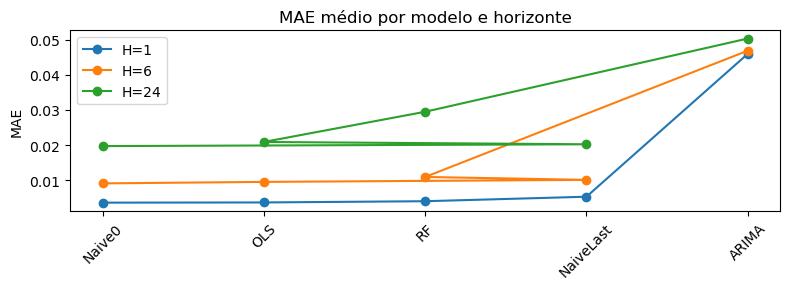

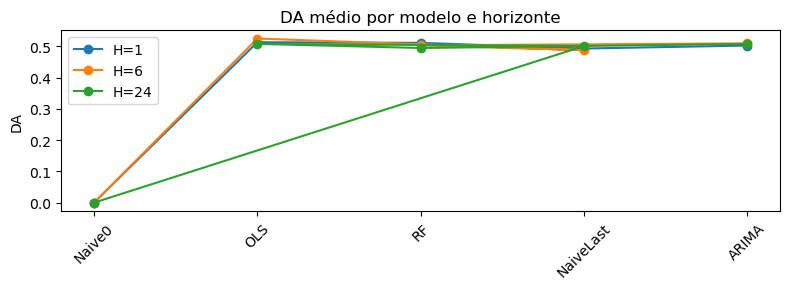

In [15]:
# %% 11 – (Opcional) Quick view gráfico dos resultados

import matplotlib.pyplot as plt

for metric in ["MAE", "DA"]:
    plt.figure(figsize=(8, 3))
    for H in HORIZONS:
        sub = summary[summary["H"] == H]
        plt.plot(sub["Model"], sub[metric], marker="o", label=f"H={H}")
    plt.xticks(rotation=45)
    plt.ylabel(metric)
    plt.title(f"{metric} médio por modelo e horizonte")
    plt.legend()
    plt.tight_layout()
    plt.show()